# Regular TransE

In [1]:
!pip install keybert

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 115.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.1/566.1 kB 297.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 159.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 800.4/800.4 kB 463.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 171.2 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.2 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import numpy as np
import pandas as pd
import torch
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import pickle
import torch.nn as nn
import torch.optim as optim
import random
from torch.utils.data import Dataset, DataLoader
import re
import os
import json
from keybert import KeyBERT

Add the location of your preprocessed files below

In [3]:
csv_file = '../preprocess/'

Import CPE

In [4]:
df_cpe = pd.read_csv(csv_file + "csv_file/2021aug/cpe_ignore_version.csv", usecols=['part','vendor',
                'product', 'target_sw','target_hw','name','size']).sort_values(
                'size', ascending=False)

Import CVE

In [5]:
df_cve = pd.read_csv(csv_file + "csv_file/2021aug/cve/cve-2002.csv")
df_cve = df_cve.astype('object').fillna('*')
df_list = [df_cve]
for i in range(2003, 2022):
    filename = f'{csv_file}csv_file/2021aug/cve/cve-{i}.csv'
    df_temp = pd.read_csv(filename)
    df_temp = df_temp.astype('object').fillna('*')
    df_list.append(df_temp)
df_cve = pd.concat(df_list, ignore_index=True)


Import CWE

In [6]:
df_cwe = pd.read_csv(csv_file + "csv_file/2021aug/cwe.csv")
df_cwe.fillna('*', inplace=True)

df_cwe_cate = pd.read_csv(csv_file + "csv_file/2021aug/cwe_category.csv")
df_cwe_view = pd.read_csv(csv_file + "csv_file/2021aug/cwe_view.csv")
df_cwe_cate.fillna('*', inplace=True)
df_cwe_view.fillna('*', inplace=True)

Extract Top 3 Keywords from the CWE descriptions

In [7]:
kw_model = KeyBERT()

def extract_keywords(text, top_k=3):
    if not isinstance(text, str):
        return []
    keywords = kw_model.extract_keywords(text, keyphrase_ngram_range=(1, 1), stop_words='english', top_n=top_k)
    return [kw for kw, _ in keywords]

Below is an example of the keywords extracted from a CWE description

In [8]:
print(df_cwe.loc[9, 'Name'])
extract_keywords(df_cwe.loc[9, 'Name'])

"Processor Optimization Removal or Modification of Security-critical Code"


['processor', 'modification', 'security']

In [9]:
triples_key = []
for _, row in df_cwe.iterrows():
    cve_id = row['ID']
    desc = row['Name']
    keywords = extract_keywords(desc)
    for kw in keywords:
        triples_key.append([cve_id, 'has_keyword', kw])

for _, row in df_cwe_cate.iterrows():
    cve_id = row['ID']
    desc = row['Name']
    keywords = extract_keywords(desc)
    for kw in keywords:
        triples_key.append([cve_id, 'has_keyword', kw])


for _, row in df_cwe_view.iterrows():
    cve_id = row['ID']
    desc = row['Name']
    keywords = extract_keywords(desc)
    for kw in keywords:
        triples_key.append([cve_id, 'has_keyword', kw])


In [10]:
print("The size of df_cpe, df_cve, df_cwe are:", df_cpe.shape[0], df_cve.shape[0], df_cwe.shape[0])

The size of df_cpe, df_cve, df_cwe are: 68338 167542 918


In [11]:
cwe_list = []

kg_cwe = []

for i, r in df_cwe.iterrows():
    cweid = r['ID']

    cwe_list.append(cweid)

    if (r['Related_Weakness'] != '*'):
        relatedlist = r['Related_Weakness'].split(';')
        for re in relatedlist:
            relation, other = re.split(':')
            other = 'CWE-' + other
            kg_cwe.append(([cweid, relation, other]))

    if (r['Language'] != '*'):
        langlist = r['Language'].split(';')
        for l in langlist:
            if (l != 'Language-Independent'):
                kg_cwe.append(([cweid, 'Language', l]))

    if (r['Technology'] != '*'):
        techlist = r['Technology'].split(';')
        for t in techlist:
            if (t != 'Technology-Independent'):
                kg_cwe.append(([cweid, 'Technology', t]))

    if (r['Likelihood_Of_Exploit'] != '*'):
        kg_cwe.append(([cweid, 'LikelihoodOfExploit', \
                        r['Likelihood_Of_Exploit']]))

    if (r['Consequence'] != '*'):
        conseqlist = r['Consequence'].split(';')
        for c in conseqlist:
            if (c != 'Other'):
                kg_cwe.append(([cweid, 'Consequence', c]))

In [12]:
kg_cate = []
kg_view = []

for i, r in df_cwe_cate.iterrows():
    cid = r['ID']

    if (r['Has_Member'] != '*'):
        memlist = r['Has_Member'].split(';')
        for m in memlist:
            kg_cate.append(([cid, 'Has_Member', m]))

for i, r in df_cwe_view.iterrows():
    vid = r['ID']

    if (r['Has_Member'] != '*'):
        memlist = r['Has_Member'].split(';')
        for m in memlist:
            kg_view.append(([vid, 'Has_Member', m]))

In [13]:
cpe_candidate_list = df_cpe['name'].values.tolist()

In [14]:
cve_candidate_list = []
connected_cvelist = []

kg_cve = []
kg_cpe2cve = []
kg_cve2cwe = []

connected_cpelist = []

for i, r in tqdm(df_cve.iterrows(), total = len(df_cve)):
    cveid = r['ID']
    cve_candidate_list.append(cveid)
    is_connected = 0

    if (r['MatchingCPE'] != '*'):
        cpes_related = r['MatchingCPE'].split(';')
        plist = []
        for p in cpes_related:

            p = p.replace('\,', '\.')
            p = p.replace('\:', '\;')
            p = p.replace('"', "'")

            p_detail = p.split(':')
            pp = ':'.join(['cpe']+p_detail[2:5]+p_detail[10:12])
            if (pp not in plist)  and (pp in cpe_candidate_list):
                matchcpe = [pp, 'MatchingCVE', cveid]
                kg_cpe2cve.append((matchcpe))
                is_connected += 1

            if pp not in connected_cpelist and (pp in cpe_candidate_list):
                connected_cpelist.append(pp)

            plist.append(pp)

    if (r['MatchingCWE'] != '*' and r['MatchingCWE'] != 'NVD-CWE-Other' and r['MatchingCWE'] != 'NVD-CWE-noinfo'):
        cwelist = r['MatchingCWE'].split(';')
        for w in cwelist:
            if (w != 'NVD-CWE-noinfo') and (w in cwe_list or w in df_cwe_cate['ID'].values.tolist() or w in df_cwe_view['ID'].values.tolist()):
                if w=='CWE-17':
                    print(cveid, w)
                matchcwe = [cveid, 'MatchingCWE', w]
                kg_cve2cwe.append((matchcwe))
                is_connected += 1

    if is_connected:
        connected_cvelist.append(cveid)
        is_connected = 0

kg_cve = kg_cpe2cve + kg_cve2cwe

  0%|          | 0/167542 [00:00<?, ?it/s]

In [15]:
with open('./saved/cpelist_connected.txt', 'w') as f:
    for items in connected_cpelist:
        f.write('%s\n' %items)
    print("File written successfully")
f.close()

File written successfully


In [16]:
with open('./saved/cvelist_connected.txt', 'w') as f:
    for items in connected_cvelist:
        f.write('%s\n' %items)
    print("File written successfully")
f.close()

File written successfully


In [17]:
f = open('./saved/cpelist_connected.txt', 'r')
connected_cpelist = f.read().splitlines()
f.close()

In [18]:
f = open('./saved/cvelist_connected.txt', 'r')
connected_cvelist = f.read().splitlines()
f.close()

In [19]:
filtered_df = df_cve[df_cve['ID'].isin(connected_cvelist)].copy()

for _, row in tqdm(filtered_df.iterrows(), total=len(filtered_df)):
    cve_id = row['ID']
    desc = row['description']
    keywords = extract_keywords(desc)
    for kw in keywords:
        triples_key.append([cve_id, 'has_keyword', kw])
    

  0%|          | 0/139732 [00:00<?, ?it/s]

In [20]:
cpe2cve_df = pd.DataFrame(kg_cpe2cve, columns=["subject", "predicate", "object"])
cpe2cve_df.to_csv('./saved/cpe2cve-aug2021.csv', index=False)

cve2cwe_df = pd.DataFrame(kg_cve2cwe, columns=["subject", "predicate", "object"])
cve2cwe_df.to_csv('./saved/cve2cwe-aug2021.csv', index=False)

In [21]:
# Load data
kg_cpe2cve_df = pd.read_csv("./saved/cpe2cve-aug2021.csv")
kg_cve2cwe_df = pd.read_csv("./saved/cve2cwe-aug2021.csv")

# Convert to list of triples using .values.tolist()
kg_cpe2cve = kg_cpe2cve_df[['subject', 'predicate', 'object']].values.tolist()
kg_cve2cwe = kg_cve2cwe_df[['subject', 'predicate', 'object']].values.tolist()

# Combine the two
kg_cve = kg_cpe2cve + kg_cve2cwe

In [22]:
kg_cpe = []

for i, r in df_cpe.iterrows():
    cpeid = r['name']

    if cpeid in connected_cpelist:
        kg_cpe.append([cpeid, "Part", r['part']])
        kg_cpe.append([cpeid, "Vendor", r['vendor']])
        kg_cpe.append([cpeid, "Product", r['product']])
        if (r['target_sw'] != "*"):
            kg_cpe.append([cpeid, "Target_sw", r['target_sw']])
        if (r['target_hw'] != "*"):
            kg_cpe.append([cpeid, "Target_hw", r['target_hw']])

In [23]:
triples = kg_cpe + kg_cve + kg_cwe + kg_cate + kg_view + triples_key

In [24]:
triples_df = pd.DataFrame(triples, columns=["subject", "predicate", "object"])
triples_df.to_csv('./saved/kg_demo_aug2021.csv', index=False)

### Model Initialization

In [25]:
triples_df = pd.read_csv("./saved/kg_demo_aug2021.csv", usecols=["subject", "predicate", "object"])
triples = triples_df[['subject', 'predicate', 'object']].values.tolist()

In [26]:
triples_df.shape

(842844, 3)

Below we produce dictionaries for entity (head or tail) and relation conversions to a number (ID). For example, CWE-200 could have an ID of 2587. These are necessary when training the model.

In [27]:
entities = set()
relations = set()
for triple in triples:
    h, r, t = triple
    entities.add(h)
    entities.add(t)
    relations.add(r)

print(f"Number of entities: {len(entities)}")
print(f"Number of relations: {len(relations)}")
num_entities = len(entities)
num_relations = len(relations)

# must be sorted to produce identical remappings if code block is run again
entity2id = {entity: idx for idx, entity in sorted(enumerate(entities))}
id2entity = {idx: entity for entity, idx in entity2id.items()}

relation2id = {relation: idx for idx, relation in sorted(enumerate(relations))}
id2relation = {idx: relation for relation, idx in relation2id.items()}

triples_id = []
for h, r, t in triples:
    triples_id.append([entity2id[h], relation2id[r], entity2id[t]])
triples_id = np.array(triples_id)


Number of entities: 262321
Number of relations: 19


The same ID - entity/relation mappings must be used for model training and evaluation to see accurate and consistent results. As a result, we save the ID conversions below to load them later.

In [28]:
ex = "_other3"
with open(f"id_conversions{ex}/entity2id.pkl", "wb") as f:
    pickle.dump(entity2id, f)

with open(f"id_conversions{ex}/id2entity.pkl", "wb") as f:
    pickle.dump(id2entity, f)

with open(f"id_conversions{ex}/relation2id.pkl", "wb") as f:
    pickle.dump(relation2id, f)

with open(f"id_conversions{ex}/id2relation.pkl", "wb") as f:
    pickle.dump(id2relation, f)

np.save(f"id_conversions{ex}/triples_id.npy", triples_id)


In [29]:
class TransE(nn.Module):
    def __init__(self, num_entities, num_relations, embedding_dim):
        super(TransE, self).__init__()
        self.num_entities = num_entities
        self.num_relations = num_relations
        self.embedding_dim = embedding_dim

        self.entity_embeddings = nn.Embedding(num_entities, embedding_dim)
        self.relation_embeddings = nn.Embedding(num_relations, embedding_dim)
 

        nn.init.xavier_uniform_(self.entity_embeddings.weight.data)
        nn.init.xavier_uniform_(self.relation_embeddings.weight.data)

    def forward(self, pos_triples, neg_triples):
        pos_score = self.score_triples(pos_triples)

        # reshaping b/c >1 neg triple per pos triple 
        # (batch_size, num_neg, 3) -> (batch_size * num_neg, 3)
        batch_size, num_neg, _ = neg_triples.shape
        neg_triples = neg_triples.view(-1, 3)

        neg_score = self.score_triples(neg_triples)
        return pos_score, neg_score

    def predict(self, triples):
        return self.score_triples(triples)

    # transe scoring - higher score = better fit.
    # this can be changed for distmult (h*r*t) or complex
    def score_triples(self, triples):
        h = self.entity_embeddings(triples[:, 0])
        r = self.relation_embeddings(triples[:, 1])
        t = self.entity_embeddings(triples[:, 2])

        # ampligraph defaults to l1 norm
        score = -torch.norm(h + r - t, p=1, dim=1)
        return score

The below code is an implementation of the Multiclass Negative Log Likelihood that we use in AmpliGraph 1.4.0. The loss function was implemented by referring to AmpliGraph's [source code](https://github.com/Accenture/AmpliGraph/blob/develop/ampligraph/latent_features/loss_functions.py). 

In [30]:
#ensure against integer overflow
def clip_before_exp(x):
    return torch.clamp(x, max=75.0, min=-75.0)


def loss_function(pos_score, neg_score, model, lambda_reg=1e-5):
    # Shape assumptions:
    # pos_score: (batch_size,) or (batch_size, 1)
    # neg_score: (batch_size, num_neg)

    pos_score = pos_score.view(-1, 1)  # (batch_size, 1)
    neg_score = neg_score.view(pos_score.size(0), -1)  # (batch_size, num_neg)

    # Clip before exp like AmpliGraph
    pos_score_clipped = clip_before_exp(pos_score)
    neg_score_clipped = clip_before_exp(neg_score)

    pos_exp = torch.exp(pos_score_clipped)
    neg_exp_sum = torch.sum(torch.exp(neg_score_clipped), dim=1, keepdim=True)

    softmax_score = pos_exp / (pos_exp + neg_exp_sum + 1e-10)
    loss = -torch.log(softmax_score + 1e-10) 
    loss = loss.sum()
    #regularizer
    l3_loss = sum(torch.sum(torch.abs(param) ** 3) for param in [model.entity_embeddings.weight, model.relation_embeddings.weight])
    return loss + lambda_reg * l3_loss

In [31]:
class KGDataset(Dataset):
    def __init__(self, triples):
        self.triples = triples

    def __len__(self):
        return len(self.triples)

    def __getitem__(self, idx):
        return self.triples[idx]

In the AmpliGraph implementation of the model, we generate negative triples for each positive triple.
```python
model_transe = TransE(batches_count=50,
    epochs=300,
    k=100,
    eta=20,
    embedding_model_params={'corrupt_sides': ['s,o'], 'negative_corruption_entities': 'batch'},
    optimizer='adam',
    optimizer_params={'lr':1e-4},
    loss='multiclass_nll',
    regularizer="LP",
    regularizer_params={'p':3, 'lambda':1e-5},
    seed=0,
    verbose=True)
```
The ```embedding_model_params```argument specifies this. We corrupt either the subject or object and we produce these corruptions by selecting any of the entities in the same batch, which is specified by the ```negative_corruption_entities``` key. The following function mimics this behavior by first receiving all entities in the specific batch and producing ```eta=20``` negative triples for each positive triple.

In [32]:
def generate_batch_negatives(pos_triples, entity_ids, eta=20, corrupt_head_prob=0.5):
    batch_size = pos_triples.shape[0]
    device = pos_triples.device

    # randomly decide whether to corrupt head or tail 1-head, 0-tail
    # batch_size*eta for each neg triple per pos triple in batch
    corrupt_heads = torch.rand(batch_size * eta, device=device) < corrupt_head_prob

    # Repeat positive triples eta times
    pos_repeated = pos_triples.repeat_interleave(eta, dim=0)

    # batch entities to choose from when corrupting
    entity_ids = torch.tensor(entity_ids, device=device)
    # get random entities to use when corrupting h or t
    corrupt_ents = entity_ids[torch.randint(0, len(entity_ids), (batch_size * eta,), device=device)]

    # Clone and corrupt
    neg_triples = pos_repeated.clone()
    neg_triples[corrupt_heads, 0] = corrupt_ents[corrupt_heads]
    neg_triples[~corrupt_heads, 2] = corrupt_ents[~corrupt_heads]

    # reshape back to (batch_size, eta, 3)
    return neg_triples.view(batch_size, eta, 3)


### Model Training

All the hyperparameters below are similar to the AmpliGraph implementation except for the number of epochs. I used the validation set to determine when to stop training but it usually takes less than 100 epochs.

In [33]:
#reproducible performance
num = 0
random.seed(num)
np.random.seed(num)
torch.manual_seed(num)
torch.cuda.manual_seed(num)
torch.use_deterministic_algorithms(True)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

embedding_dim = 100
lambda_reg = 1e-5
num_epochs = 75
batches_count = 50
eta = 20  # number of negative triples per positive triple
learning_rate = 1e-4

batch_size = int(len(triples_id)/batches_count)
train_dataset = KGDataset(triples_id)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=embedding_dim
).to(device)


optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in tqdm(range(num_epochs)):
    model.train()
    total_loss = 0
    
    for pos_triples in train_loader:
        pos_triples = pos_triples.long().to(device)
        # get unique entities (head and tail) in the current batch
        batch_entities = pos_triples[:, [0, 2]].unique().tolist()
        # generate negatives from batch entities only
        neg_triples = generate_batch_negatives(pos_triples, batch_entities, eta=eta)
        neg_triples = neg_triples.long().to(device)
        optimizer.zero_grad()
        pos_score, neg_score = model(pos_triples, neg_triples)
        loss = loss_function(pos_score, neg_score, model, lambda_reg)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_loss:.4f}")

Using device: cuda


  0%|          | 0/75 [00:00<?, ?it/s]

Epoch 1/75, Loss: 48984.7468
Epoch 2/75, Loss: 46403.1045
Epoch 3/75, Loss: 44463.7510
Epoch 4/75, Loss: 42946.6477
Epoch 5/75, Loss: 41727.5585
Epoch 6/75, Loss: 40707.3083
Epoch 7/75, Loss: 39811.2850
Epoch 8/75, Loss: 39035.4513
Epoch 9/75, Loss: 38333.3701
Epoch 10/75, Loss: 37683.3073
Epoch 11/75, Loss: 37068.2703
Epoch 12/75, Loss: 36487.6375
Epoch 13/75, Loss: 35934.9399
Epoch 14/75, Loss: 35423.3179
Epoch 15/75, Loss: 34906.3664
Epoch 16/75, Loss: 34429.8705
Epoch 17/75, Loss: 33968.6140
Epoch 18/75, Loss: 33523.3157
Epoch 19/75, Loss: 33070.9661
Epoch 20/75, Loss: 32634.3561
Epoch 21/75, Loss: 32202.7655
Epoch 22/75, Loss: 31804.7673
Epoch 23/75, Loss: 31387.6784
Epoch 24/75, Loss: 31007.9780
Epoch 25/75, Loss: 30627.7302
Epoch 26/75, Loss: 30239.9492
Epoch 27/75, Loss: 29858.2306
Epoch 28/75, Loss: 29483.6839
Epoch 29/75, Loss: 29124.0817
Epoch 30/75, Loss: 28757.7610
Epoch 31/75, Loss: 28391.4697
Epoch 32/75, Loss: 28051.1568
Epoch 33/75, Loss: 27684.8603
Epoch 34/75, Loss: 

Save Model

In [35]:
torch.save(model.state_dict(), "models/transe_model_nll_other3.pt")
model.eval()

TransE(
  (entity_embeddings): Embedding(262321, 100)
  (relation_embeddings): Embedding(19, 100)
)

Load Model and ID Conversions for evaluation below

In [36]:
ex = "_other3"
with open(f"id_conversions{ex}/entity2id.pkl", "rb") as f:
    entity2id = pickle.load(f)

with open(f"id_conversions{ex}/id2entity.pkl", "rb") as f:
    id2entity = pickle.load(f)

with open(f"id_conversions{ex}/relation2id.pkl", "rb") as f:
    relation2id = pickle.load(f)

with open(f"id_conversions{ex}/id2relation.pkl", "rb") as f:
    id2relation = pickle.load(f)

triples_id = np.load(f"id_conversions{ex}/triples_id.npy")

In [37]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = TransE(
    num_entities=len(entity2id),
    num_relations=len(relation2id),
    embedding_dim=100
)

# Load the saved weights
model.load_state_dict(torch.load("models/transe_model_nll_other3.pt", map_location=device))
model.to(device)

# remove this if you just want to continue training
model.eval()  # set to evaluation mode


TransE(
  (entity_embeddings): Embedding(262321, 100)
  (relation_embeddings): Embedding(19, 100)
)

### Open World Evaluation of Model

In [38]:
kg_cpe2cve_nov2022_df = pd.read_csv("./saved/cpe2cve-nov2022.csv")
kg_cpe2cve_nov2022 = kg_cpe2cve_nov2022_df[['subject', 'predicate', 'object']].values.tolist()

kg_cve2cwe_2022_df = pd.read_csv("./saved/cve2cwe-nov2022.csv")
kg_cve2cwe_nov2022 = kg_cve2cwe_2022_df[['subject', 'predicate', 'object']].values.tolist()

In [39]:
new_cve2cwe = []

li1 = []
li2 = []
for l in kg_cve2cwe_nov2022:
    li1.append(l[0]+','+l[1]+','+l[2])
for l in kg_cve2cwe:
    li2.append(l[0]+','+l[1]+','+l[2])

new_tmp = list(set(li1) - set(li2))
for s in new_tmp:
    new_cve2cwe.append(s.split(','))

new_cve2cwe_df = pd.DataFrame(new_cve2cwe, columns=["subject", "predicate", "object"]).sort_values(by=['subject'], ascending=True).reset_index(drop=True)

In [40]:
# keep only the relations between existing nodes
new_test_cve2cwe = []

kg_cve2cwe_df = pd.DataFrame(kg_cve2cwe, columns=["subject", "predicate", "object"])
for i, r in new_cve2cwe_df.iterrows():
    if r['subject'] in connected_cvelist:
        new_test_cve2cwe.append(r)

In [41]:
# save new_test_cve2cwe locally
new_test_cve2cwe_df = pd.DataFrame(new_test_cve2cwe, columns=["subject", "predicate", "object"])
new_test_cve2cwe_df.to_csv('./saved/new_test_cve2cwe_aug2021_nov2022.csv', index=False)

In [42]:
new_cpe2cve = []

li1 = []
li2 = []
for l in kg_cpe2cve_nov2022:
    li1.append(l[0]+','+l[1]+','+l[2])
for l in kg_cpe2cve:
    li2.append(l[0]+','+l[1]+','+l[2])

new_tmp = list(set(li1) - set(li2))
for s in new_tmp:
    new_cpe2cve.append(s.split(','))

new_cpe2cve_df = pd.DataFrame(new_cpe2cve, columns=["subject", "predicate", "object"]).sort_values(by=['subject'], ascending=True).reset_index(drop=True)

In [43]:
# keep only the relations between existing nodes
new_test_cpe2cve = []

kg_cpe2cve_df = pd.DataFrame(kg_cpe2cve, columns=["subject", "predicate", "object"])
for i, r in new_cpe2cve_df.iterrows():
    if r['subject'] in connected_cpelist:
        if r['object'] in connected_cvelist:
            new_test_cpe2cve.append(r)

In [44]:
# save new_test_cpe2cve locally
new_test_cpe2cve_df = pd.DataFrame(new_test_cpe2cve, columns=["subject", "predicate", "object"])
new_test_cpe2cve_df.to_csv('./saved/new_test_cpe2cve_aug2021_nov2022.csv', index=False)

In [45]:
# Load new_test_cve2cwe
new_test_cve2cwe_df = pd.read_csv("./saved/new_test_cve2cwe_aug2021_nov2022.csv")
new_test_cve2cwe = new_test_cve2cwe_df[['subject', 'predicate', 'object']].values.tolist()

# Load new_test_cpe2cve
new_test_cpe2cve_df = pd.read_csv("./saved/new_test_cpe2cve_aug2021_nov2022.csv")
new_test_cpe2cve = new_test_cpe2cve_df[['subject', 'predicate', 'object']].values.tolist()

In [46]:
cwe_list = df_cwe['ID'].values.tolist()

The following evaluation is for new CVE-CWE and CPE-CVE mappings (open-world) specifically. To evaluate CVE-CWE mappings, we replace the CWE with all other CWEs (which form negative triples) and see if the one that is the true mapping ranks higher than all the negative triples. Similary, for CPE-CVE mappings, we replace the CPE with all other CPEs. The ```known_triples_set``` argument makes sure that the potential "corrupted triples" are not also positive triples. If they are, it ignores that that corrupted triple. It filters out any positive triples from the set of corrupted triples if that happens.

In [47]:
#used for evaluation
def mr_score(ranks):
    return np.mean(ranks)


def mrr_score(ranks):
    return np.mean([1.0 / rank for rank in ranks])


def hits_at_n(ranks, n):
    return np.mean([rank <= n for rank in ranks])

---------------CPE-CVE-----------------


  0%|          | 0/12399 [00:00<?, ?it/s]

Mean Rank: 937.8841842084039
Hits@1: 0.07734494717315912
Hits@3: 0.1767077990160497
Hits@10: 0.3092991370271796
Hits@20: 0.3801919509637874
MRR: 0.1554664312814371


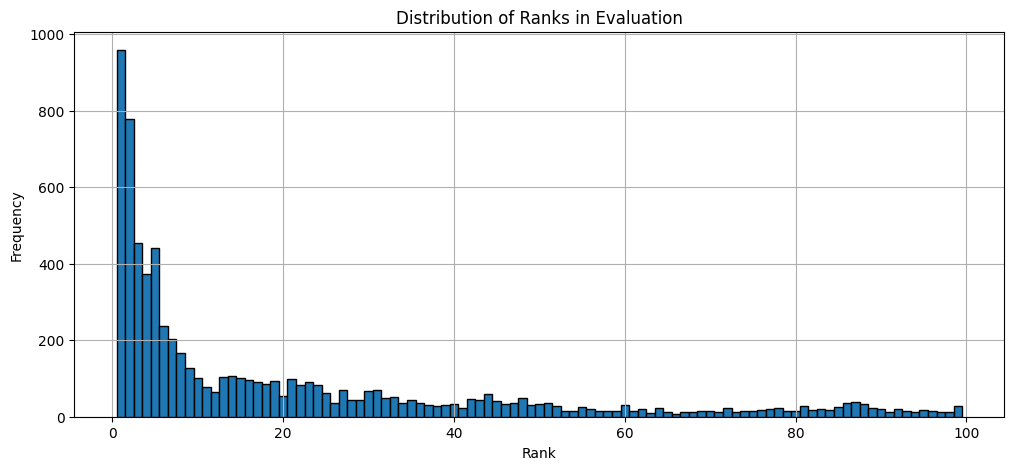

---------------CVE-CWE-----------------


  0%|          | 0/1698 [00:00<?, ?it/s]

Mean Rank: 30.22143698468787
Hits@1: 0.08539458186101295
Hits@3: 0.22732626619552415
Hits@10: 0.4623085983510012
Hits@20: 0.6295641931684335
MRR: 0.2083710077270277


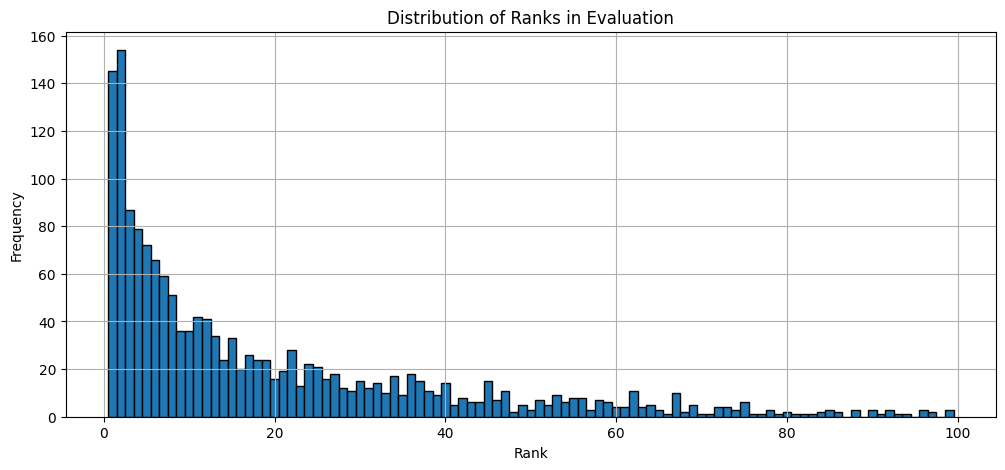

In [48]:
def evaluate_model(model, test_triples, all_entities, known_triples_set, corrupt_side='tail'):
    model.eval()
    ranks = []
    with torch.no_grad():
        for idx in tqdm(range(len(test_triples))):
            h, r, t = test_triples[idx]
            h_id = torch.tensor([h], device=device).long()
            r_id = torch.tensor([r], device=device).long()
            t_id = torch.tensor([t], device=device).long()

            corrupted_entities = []
            for e in all_entities:
                if corrupt_side == 'tail':
                    if e != t:
                        candidate = (h, r, e)
                elif corrupt_side == 'head':  # corrupt head
                    if e != h:
                        candidate = (e, r, t)
                else:
                    continue
                if candidate not in known_triples_set:
                    corrupted_entities.append(e)

            corrupted_entities = torch.tensor(corrupted_entities, device=device).long()

            if corrupt_side == 'tail':
                h_ids = h_id.repeat(len(corrupted_entities))
                r_ids = r_id.repeat(len(corrupted_entities))
                t_ids = corrupted_entities
                true_triple = torch.tensor([[h, r, t]], device=device).long()
            else:
                h_ids = corrupted_entities
                r_ids = r_id.repeat(len(corrupted_entities))
                t_ids = t_id.repeat(len(corrupted_entities))
                true_triple = torch.tensor([[h, r, t]], device=device).long()

            corrupted_triples = torch.stack((h_ids, r_ids, t_ids), dim=1)
            corrupted_scores = model.predict(corrupted_triples)
            true_score = model.predict(true_triple)

            all_scores = torch.cat([true_score, corrupted_scores])
            sorted_scores, indices = torch.sort(all_scores, descending=True)
            rank = (indices == 0).nonzero(as_tuple=True)[0].item() + 1
            ranks.append(rank)
    
    print(f"Mean Rank: {mr_score(ranks)}")
    for k in [1, 3, 10, 20]:
        print(f"Hits@{k}: {hits_at_n(ranks, k)}")
    print(f"MRR: {mrr_score(ranks)}")
    plt.figure(figsize=(12, 5))
    n, bins, patches = plt.hist(ranks, bins=range(1, 101), edgecolor='black', align='left')
    plt.xlabel('Rank')
    plt.ylabel('Frequency')
    plt.title('Distribution of Ranks in Evaluation')
    
    plt.grid(True)
    plt.show()
    return ranks

print("---------------CPE-CVE-----------------")
test_triples = []
for h, r, t in new_test_cpe2cve:
    test_triples.append([entity2id[h], relation2id[r], entity2id[t]])

tails = [entity2id[e] for e in connected_cpelist]
num_test_triples = len(test_triples)
known_triples_set = set(tuple([h, r, t]) for h, r, t in np.vstack((triples_id, test_triples)))
ranks = evaluate_model(model, test_triples[:num_test_triples], tails, known_triples_set, corrupt_side='head')

print("---------------CVE-CWE-----------------")
test_triples = []
for h, r, t in new_test_cve2cwe:
    test_triples.append([entity2id[h], relation2id[r], entity2id[t]])

tails = [entity2id[e] for e in cwe_list]
num_test_triples = len(test_triples)
known_triples_set = set(tuple([h, r, t]) for h, r, t in np.vstack((triples_id, test_triples)))
ranks = evaluate_model(model, test_triples[:num_test_triples], tails, known_triples_set, corrupt_side='tail')

In [49]:
df_cwe_1003 = pd.read_csv("../FixV2W/files/cwe-1003.csv", usecols=['CWE-ID', 'Weakness Abstraction'], index_col=False)
df_cwe_1003.fillna('*', inplace=True)
cwe_rels = pd.read_csv("../FixV2W/files/cwe_relations.csv")

cwe_sublist = []  # does not contain discouraged cwe from cwe-1003 list
cwe_1003 = []
cwe_disc = ["CWE-119", "CWE-20", "CWE-200", "CWE-269", "CWE-287",
            "CWE-311", "CWE-330", "CWE-345", "CWE-400", "CWE-610",
            "CWE-662", "CWE-665", "CWE-668", "CWE-682", "CWE-697",
            "CWE-74", "CWE-755", "CWE-834", "CWE-284", "CWE-285", "CWE-287",
            "CWE-693", "CWE-788"]
for i, r in df_cwe_1003.iterrows():
    cweid = 'CWE-' + str(r['CWE-ID'])
    cwe_abs = r['Weakness Abstraction']
    cwe_1003.append(cweid)

    if cweid not in cwe_disc:
        cwe_sublist.append((cweid, cwe_abs))


In [114]:
df_cve['MatchingCWE'].value_counts()[:10]

MatchingCWE
NVD-CWE-Other     26650
NVD-CWE-noinfo    17389
CWE-79            16035
CWE-119           11196
*                  9869
CWE-20             7825
CWE-89             6582
CWE-200            6417
CWE-264            5134
CWE-787            3925
Name: count, dtype: int64

Filtered test triples (noinfo→something): 104
---------------CVE (noinfo→something) -----------------


  0%|          | 0/104 [00:00<?, ?it/s]

Mean Rank: 40.24038461538461
Hits@1: 0.04807692307692308
Hits@3: 0.10576923076923077
Hits@10: 0.2692307692307692
Hits@20: 0.4326923076923077
MRR: 0.12075094426227531


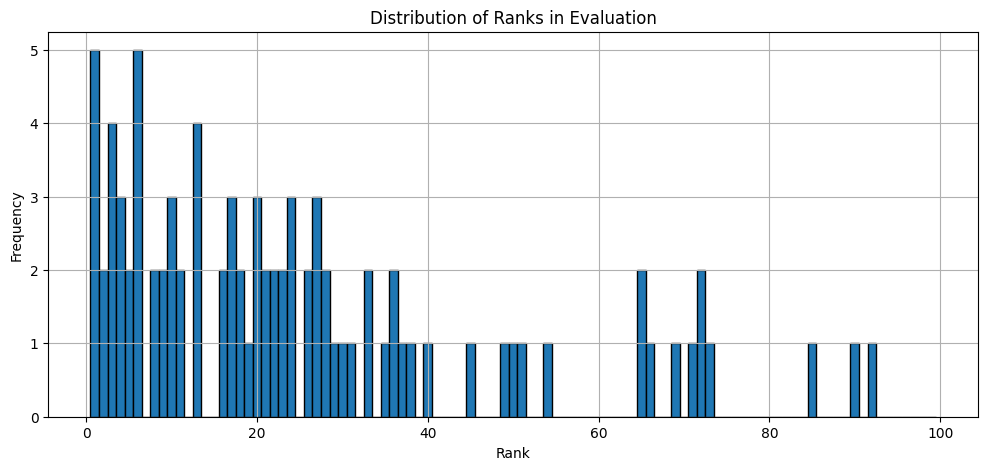

In [109]:
# --- Step 1: Filter CVEs that were "noinfo"/"other" originally ---
noinfo_cves = set(df_cve.loc[
    df_cve['MatchingCWE'].str.lower().isin(['nvd-cwe-noinfo', 'nvd-cwe-other', '*']),
    'ID'
])

# --- Step 2: Keep only test triples whose head (CVE) was in that set ---
filtered_test_triples = []
for h, r, t in new_test_cve2cwe:
    if h in noinfo_cves:
        filtered_test_triples.append([entity2id[h], relation2id[r], entity2id[t]])

print(f"Filtered test triples (noinfo→something): {len(filtered_test_triples)}")

# --- Step 3: Candidate tails are all CWEs in cwe_1003 ---
candidate_tails = [entity2id[e] for e in cwe_1003]

# --- Step 4: Build known triples set to filter existing ones ---
known_triples_set = set(tuple([h, r, t]) for h, r, t in triples_id)

# --- Step 5: Evaluate ---
print("---------------CVE (noinfo→something) -----------------")
ranks_noinfo = evaluate_model(
    model,
    filtered_test_triples,
    candidate_tails,
    known_triples_set,
    corrupt_side='tail'
)
